<a href="https://colab.research.google.com/github/Shibu09-tech/AI-ML-Projects-and-Notes/blob/main/Lab3_Data_Cleaning_and_Preprocessing_Techniques/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Cleaning and Preprocessing using Pandas and Scikit-learn


The aim of this lab is to perform data cleaning and preprocessing techniques on a dataset using Pandas and Scikit-learn. The lab focuses on handling missing values, detecting and removing outliers, encoding categorical features, and scaling numerical data to prepare the dataset for machine learning.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings


<function warnings.filterwarnings(action, message='', category=<class 'Warning'>, module='', lineno=0, append=False)>

In [ ]:
df=pd.read_csv('/content/Titanic-Dataset.csv')

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [ ]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### **Checking Missing Values**

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


### **Handle Missing Values**

In [ ]:
#Handling missing values in Age column using mean

df['Age'].fillna(df['Age'].mean(),inplace=True)

/tmp/ipykernel_3172/2976898699.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace=True)


In [ ]:
#Handling missing values in Embarked column using mode

df['Embarked'].fillna(df['Embarked'].mode()[0],inplace=True)

/tmp/ipykernel_3172/1380531537.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0],inplace=True)


In [ ]:
#Droping Cabin column because it contains many missing values
df.drop('Cabin',axis=1,inplace= True)

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


### **Removing Unnecessary Columns**

In [ ]:
df.drop(
    ['Name', 'Ticket', 'PassengerId'],
    axis=1,
    inplace=True
)

### **Detecting Outliers**

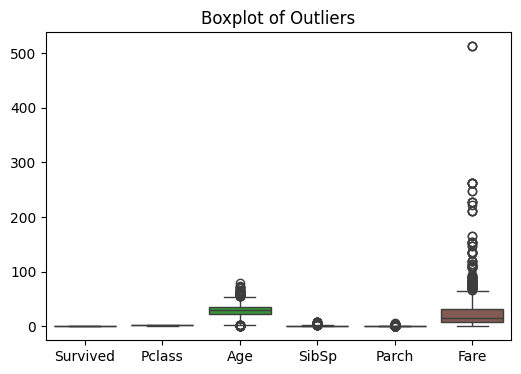

In [ ]:
plt.figure(figsize=(6,4))

sns.boxplot(data=df)

plt.title("Boxplot of Outliers")

plt.show()

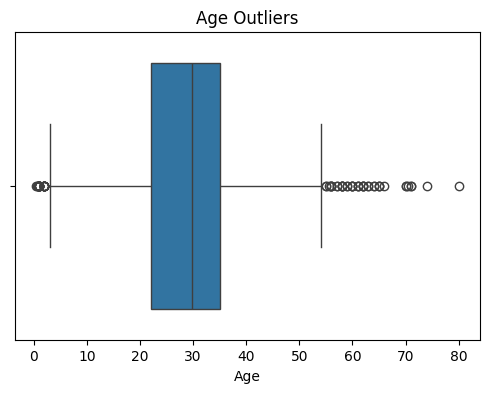

In [ ]:
plt.figure(figsize=(6,4))

sns.boxplot(x=df['Age'])

plt.title('Age Outliers')

plt.show()

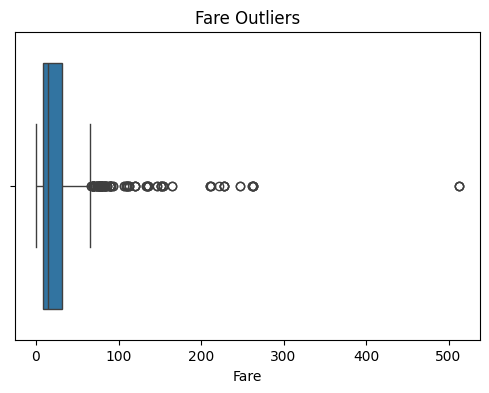

In [ ]:
plt.figure(figsize=(6,4))

sns.boxplot(x=df['Fare'])

plt.title('Fare Outliers')

plt.show()

### **Remove Outliers using IQR Method**

In [ ]:
Q1 = df['Fare'].quantile(0.25)

Q3 = df['Fare'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

data = df[
    (df['Fare'] >= lower_limit) &
    (df['Fare'] <= upper_limit)
]

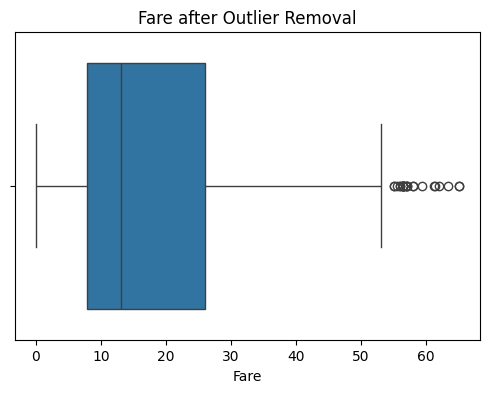

In [ ]:
plt.figure(figsize=(6,4))

sns.boxplot(x=data['Fare'])

plt.title('Fare after Outlier Removal')

plt.show()

### **Encode Categorical Features**

In [ ]:
encoder = LabelEncoder()

categorical_columns = [
    'Sex',
    'Embarked'
]

for col in categorical_columns:
    data[col] = encoder.fit_transform(data[col])

/tmp/ipykernel_3172/3557500854.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[col] = encoder.fit_transform(data[col])
/tmp/ipykernel_3172/3557500854.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[col] = encoder.fit_transform(data[col])


In [ ]:
data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.000000,1,0,7.2500,2
2,1,3,0,26.000000,0,0,7.9250,2
3,1,1,0,35.000000,1,0,53.1000,2
4,0,3,1,35.000000,0,0,8.0500,2
5,0,3,1,29.699118,0,0,8.4583,1


### **Apply Feature Scaling**

In [ ]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(data)

In [ ]:
scaled_data = pd.DataFrame(
    scaled_features,
    columns=data.columns
)

In [ ]:
scaled_data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,-0.716709,0.708528,0.677872,-0.556219,0.625606,-0.433718,-0.779117,0.539781
1,1.395266,0.708528,-1.475205,-0.243027,-0.486423,-0.433718,-0.729373,0.539781
2,1.395266,-2.016580,-1.475205,0.461654,0.625606,-0.433718,2.599828,0.539781
3,-0.716709,0.708528,0.677872,0.461654,-0.486423,-0.433718,-0.720161,0.539781
4,-0.716709,0.708528,0.677872,0.046606,-0.486423,-0.433718,-0.690071,-0.822858


In [ ]:
scaled_data.describe()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
count,7.750000e+02,7.750000e+02,7.750000e+02,7.750000e+02,7.750000e+02,7.750000e+02,7.750000e+02,7.750000e+02
mean,-3.667317e-17,3.208903e-17,-1.833659e-17,3.942366e-16,-9.168293e-18,1.719055e-17,7.334635e-17,1.661753e-16
std,1.000646e+00,1.000646e+00,1.000646e+00,1.000646e+00,1.000646e+00,1.000646e+00,1.000646e+00,1.000646e+00
min,-7.167091e-01,-2.016580e+00,-1.475205e+00,-2.245887e+00,-4.864227e-01,-4.337180e-01,-1.313411e+00,-2.185496e+00
25%,-7.167091e-01,-6.540261e-01,-1.475205e+00,-5.562186e-01,-4.864227e-01,-4.337180e-01,-7.315244e-01,5.397807e-01
50%,-7.167091e-01,7.085282e-01,6.778719e-01,4.660583e-02,-4.864227e-01,-4.337180e-01,-3.553671e-01,5.397807e-01
75%,1.395266e+00,7.085282e-01,6.778719e-01,3.833557e-01,6.256056e-01,-4.337180e-01,6.026763e-01,5.397807e-01
max,1.395266e+00,7.085282e-01,6.778719e-01,3.985058e+00,5.073719e+00,7.205634e+00,3.476807e+00,5.397807e-01


### **Correlation Heatmap**

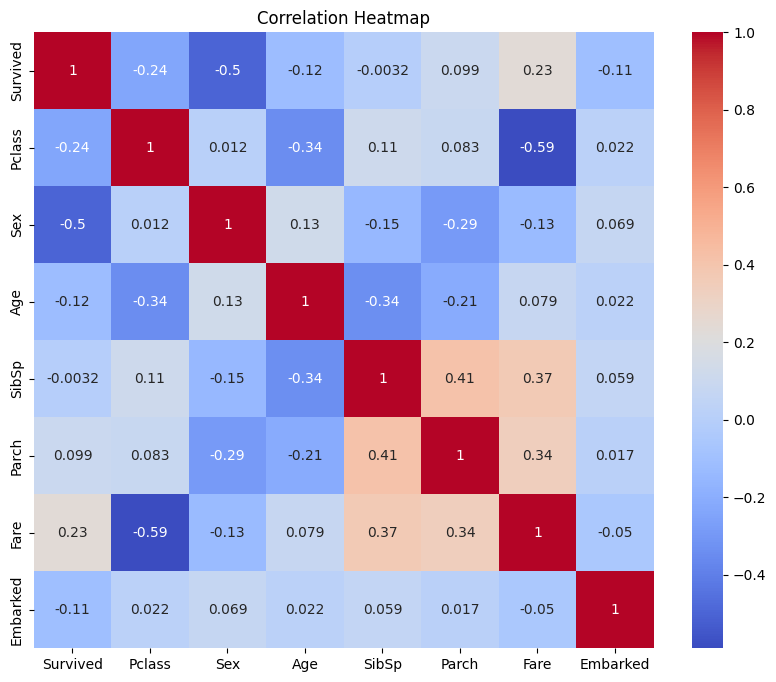

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(
    scaled_data.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

### **Save Cleaned Dataset**

In [ ]:
scaled_data.to_csv(
    'cleaned_titanic_data.csv',
    index=False
)